Importamos el csv después del preprocesado y hacemos una breve revisión para ver si nos quedó algo por hacer:
(Pequeñas pruebas de software antes de culminar el proyecto ayuda a que el proceso de prueba y testeo al final 
del proyecto sea más rápido, dado que el equipo de desarrollo es 1 sola persona)

In [1]:
import pandas as pd

df = pd.read_csv("ventas_mensuales_limpio.csv")

print(df.head())


  producto  año_mes  categoria medida  cantidad  total       fecha  mes_n  \
0   Bolsas  2023-03  Panadería      u       191  66.85  2023-03-01      0   
1   Bolsas  2023-04  Panadería      u       146  51.10  2023-04-01      1   
2   Bolsas  2023-05  Panadería      u       173  60.55  2023-05-01      2   
3   Bolsas  2023-06  Panadería      u       172  60.20  2023-06-01      3   
4   Bolsas  2023-07  Panadería      u       229  80.15  2023-07-01      4   

     media_3m  producto_cod  categoria_cod  medida_cod  
0  191.000000             0              5           1  
1  168.500000             0              5           1  
2  170.000000             0              5           1  
3  163.666667             0              5           1  
4  191.333333             0              5           1  


In [2]:
productos_x_mes = df.groupby("año_mes")
print(productos_x_mes.head())

               producto  año_mes  categoria medida  cantidad   total  \
0                Bolsas  2023-03  Panadería      u       191   66.85   
1                Bolsas  2023-04  Panadería      u       146   51.10   
2                Bolsas  2023-05  Panadería      u       173   60.55   
3                Bolsas  2023-06  Panadería      u       172   60.20   
4                Bolsas  2023-07  Panadería      u       229   80.15   
..                  ...      ...        ...    ...       ...     ...   
105        Leche entera  2024-09     Granos      u       159  795.00   
106        Leche entera  2024-10     Granos      u       160  800.00   
107        Leche entera  2024-11     Granos      u       169  845.00   
108        Leche entera  2024-12     Granos      u         1    5.00   
130  Papas precocinadas  2024-12    Lácteos      u        10   31.50   

          fecha  mes_n    media_3m  producto_cod  categoria_cod  medida_cod  
0    2023-03-01      0  191.000000             0         

Procedo con la selección de variables:

In [4]:
#como variable target vamos a elegir "cantidad"
#pues son la cantidad de ventas que se obtienen lo que queremos

#Variable TARGET (la que se desea predecir)
target_name = "cantidad"
y = df[target_name]

#Variables predictoras (las que se usarán para predecir y)
prediction_names = ["mes_n", "media_3m", "producto_cod", "categoria_cod", "medida_cod"]
x = df[prediction_names]

dfforPrediction = df[[target_name]+prediction_names].copy()

print(dfforPrediction.head())

   cantidad  mes_n    media_3m  producto_cod  categoria_cod  medida_cod
0       191      0  191.000000             0              5           1
1       146      1  168.500000             0              5           1
2       173      2  170.000000             0              5           1
3       172      3  163.666667             0              5           1
4       229      4  191.333333             0              5           1


Probaremos con regresión lineal
para ello primero probaremos si existe linealidad en el dataframe con las variables seleccionadas mediante un gráfico de dispersión:

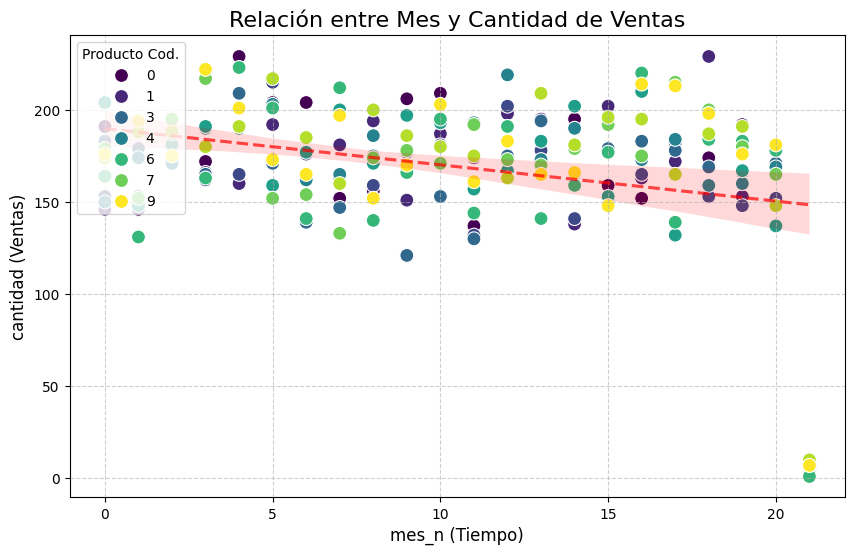

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Se recomienda usar Seaborn para visualizaciones estadísticas
plt.figure(figsize=(10, 6))

# Usamos 'hue' para ver si la relación cambia por producto_cod (variable categórica)
sns.scatterplot(x='mes_n', y='cantidad', data=dfforPrediction, hue='producto_cod', palette='viridis', s=100)

# Opcional: Agregar una línea de regresión lineal para visualizar la tendencia general
sns.regplot(x='mes_n', y='cantidad', data=dfforPrediction, scatter=False, color='red', line_kws={'linestyle': '--', 'alpha': 0.7})

plt.title('Relación entre Mes y Cantidad de Ventas', fontsize=16)
plt.xlabel('mes_n (Tiempo)', fontsize=12)
plt.ylabel('cantidad (Ventas)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Producto Cod.', loc='upper left')
plt.show()